In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [3]:
from google.colab import files
uploaded = files.upload()   # a button will appear → select TCS_New.csv

Saving TCS_New.csv to TCS_New.csv


In [5]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [6]:
DATA_PATH   = "TCS_New.csv"  # ← update if needed

SEQ_LEN     = 90          # look-back window (trading days)
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10        # remaining 10% → test

# Model hyper-parameters
INPUT_SIZE   = 9          # OHLCV + MA_10 + MA_20 + RSI + Return
LSTM_HIDDEN  = 256
LSTM_LAYERS  = 2
GRU_HIDDEN   = 128
GRU_LAYERS   = 1
DROPOUT      = 0.2
BATCH_SIZE   = 32
EPOCHS       = 150
LR           = 1e-3
PATIENCE     = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [7]:
df = pd.read_csv(DATA_PATH, skiprows=3, header=None,
                 names=["Date", "Close", "High", "Low", "Open", "Volume"])
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

for col in ["Close", "High", "Low", "Open", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.dropna(inplace=True)

In [8]:
# Moving Averages
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_20'] = df['Close'].rolling(20).mean()

# RSI (14-day) — define function first, then apply
def compute_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['RSI']    = compute_rsi(df['Close'], 14)
df['Return'] = df['Close'].pct_change()

# Drop NaN rows created by rolling windows
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset: {len(df)} rows  |  {df['Date'].min().date()} → {df['Date'].max().date()}")
print(df[["Date", "Close", "MA_10", "MA_20", "RSI", "Return"]].tail(3))

Dataset: 1217 rows  |  2021-04-01 → 2026-03-02
           Date        Close        MA_10        MA_20        RSI    Return
1214 2026-02-26  2647.699951  2670.219971  2837.295007  25.298363  0.006998
1215 2026-02-27  2637.399902  2664.739966  2812.970007  24.039436 -0.003890
1216 2026-03-02  2613.500000  2655.429956  2785.165002  18.341577 -0.009062


In [9]:
feature_cols = ["Open", "High", "Low", "Close", "Volume",
                "MA_10", "MA_20", "RSI", "Return"]
target_col   = "Close"
close_idx    = feature_cols.index(target_col)   # 3

features = df[feature_cols].values
dates    = df["Date"].values

In [10]:
n       = len(features)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
n_test  = n - n_train - n_val

train_data = features[:n_train]
val_data   = features[n_train : n_train + n_val]
test_data  = features[n_train + n_val:]
print(f"\nSplit  →  Train: {n_train}  Val: {n_val}  Test: {n_test}")


Split  →  Train: 973  Val: 121  Test: 123


In [11]:
scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

In [12]:
def build_sequences(data, seq_len, close_idx):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len, close_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = build_sequences(train_scaled, SEQ_LEN, close_idx)

val_full     = np.concatenate([train_scaled[-SEQ_LEN:], val_scaled], axis=0)
X_val, y_val = build_sequences(val_full, SEQ_LEN, close_idx)

test_full = np.concatenate([train_scaled[-SEQ_LEN:], val_scaled, test_scaled], axis=0)
X_test, y_test = [], []
for i in range(len(test_scaled)):
    X_test.append(test_full[i : i + SEQ_LEN])
    y_test.append(test_full[i + SEQ_LEN, close_idx])
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

print(f"Sequences  →  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Sequences  →  Train: (883, 90, 9)  Val: (121, 90, 9)  Test: (123, 90, 9)


In [13]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(-1)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(StockDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(StockDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

In [14]:
class BahdanauAttention(nn.Module):
    """Additive attention over the GRU output sequence."""
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)
        self.v    = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, gru_out):
        # gru_out: (batch, seq, hidden)
        energy  = torch.tanh(self.attn(gru_out))   # (batch, seq, hidden)
        scores  = self.v(energy).squeeze(-1)        # (batch, seq)
        weights = F.softmax(scores, dim=-1)         # (batch, seq)
        context = torch.bmm(weights.unsqueeze(1), gru_out).squeeze(1)  # (batch, hidden)
        return context, weights

In [15]:
class HybridLSTMGRU(nn.Module):
    """
    LSTM  →  GRU  →  Attention  →  FC head
    """
    def __init__(self, input_size, lstm_hidden, lstm_layers,
                 gru_hidden, gru_layers, dropout):
        super().__init__()

        # LSTM block
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0.0
        )
        self.lstm_norm = nn.LayerNorm(lstm_hidden)

        # GRU block
        self.gru = nn.GRU(
            input_size  = lstm_hidden,
            hidden_size = gru_hidden,
            num_layers  = gru_layers,
            batch_first = True,
            dropout     = dropout if gru_layers > 1 else 0.0
        )
        self.gru_norm = nn.LayerNorm(gru_hidden)

        # Attention
        self.attention = BahdanauAttention(gru_hidden)

        # FC head
        self.head = nn.Sequential(
            nn.Linear(gru_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # LSTM
        lstm_out, _ = self.lstm(x)              # (batch, seq, lstm_hidden)
        lstm_out    = self.lstm_norm(lstm_out)

        # GRU
        gru_out, _  = self.gru(lstm_out)        # (batch, seq, gru_hidden)
        gru_out     = self.gru_norm(gru_out)

        # Attention
        context, _  = self.attention(gru_out)   # (batch, gru_hidden)

        return self.head(context)               # (batch, 1)

model = HybridLSTMGRU(
    input_size  = INPUT_SIZE,
    lstm_hidden = LSTM_HIDDEN,
    lstm_layers = LSTM_LAYERS,
    gru_hidden  = GRU_HIDDEN,
    gru_layers  = GRU_LAYERS,
    dropout     = DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {total_params:,}")
print(model)


Model parameters: 975,745
HybridLSTMGRU(
  (lstm): LSTM(9, 256, num_layers=2, batch_first=True, dropout=0.2)
  (lstm_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (gru): GRU(256, 128, batch_first=True)
  (gru_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (attention): BahdanauAttention(
    (attn): Linear(in_features=128, out_features=128, bias=True)
    (v): Linear(in_features=128, out_features=1, bias=False)
  )
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [16]:
# ── 11. Loss, Optimiser, Scheduler ───────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5, min_lr=1e-6
)

In [17]:
# ── 12. Training loop with early stopping ────────────────────────────────────
train_losses, val_losses = [], []
best_val_loss = float("inf")
patience_ctr  = 0

print("\n── Training ──────────────────────────────────────────────────────────")
for epoch in range(1, EPOCHS + 1):

    # --- Train ---
    model.train()
    batch_losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    t_loss = np.mean(batch_losses)

    # --- Validate ---
    model.eval()
    v_losses = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            v_losses.append(criterion(model(Xb), yb).item())
    v_loss = np.mean(v_losses)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{EPOCHS}  |  "
              f"Train: {t_loss:.6f}  Val: {v_loss:.6f}  LR: {lr_now:.2e}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), "best_hybrid_model.pth")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nBest Val Loss: {best_val_loss:.6f}")


── Training ──────────────────────────────────────────────────────────
Epoch   1/150  |  Train: 0.041850  Val: 0.088957  LR: 1.00e-03
Epoch  10/150  |  Train: 0.004993  Val: 0.004797  LR: 1.00e-03
Epoch  20/150  |  Train: 0.002443  Val: 0.001373  LR: 1.00e-03
Epoch  30/150  |  Train: 0.001974  Val: 0.007674  LR: 5.00e-04

Early stopping at epoch 39.

Best Val Loss: 0.001222


In [19]:
# ── Train Accuracy ────────────────────────────────────────────────────────────
def inverse_close(vals, scaler, close_idx, n_features=9):
    dummy = np.zeros((len(vals), n_features))
    dummy[:, close_idx] = vals
    return scaler.inverse_transform(dummy)[:, close_idx]

model.eval()
train_preds_scaled, train_actuals_scaled = [], []

with torch.no_grad():
    for Xb, yb in train_loader:
        Xb = Xb.to(DEVICE)
        out = model(Xb).cpu().numpy()
        train_preds_scaled.extend(out.flatten())
        train_actuals_scaled.extend(yb.numpy().flatten())

train_preds   = inverse_close(np.array(train_preds_scaled),   scaler, close_idx)
train_actuals = inverse_close(np.array(train_actuals_scaled), scaler, close_idx)

train_mae  = mean_absolute_error(train_actuals, train_preds)
train_rmse = np.sqrt(mean_squared_error(train_actuals, train_preds))
train_mape = np.mean(np.abs((train_actuals - train_preds) / train_actuals)) * 100
train_r2   = r2_score(train_actuals, train_preds)

print("── Train Metrics ─────────────────────────────────────────────────────")
print(f"  MAE  : ₹{train_mae:.2f}")
print(f"  RMSE : ₹{train_rmse:.2f}")
print(f"  MAPE : {train_mape:.2f}%")
print(f"  R²   : {train_r2:.4f}")
print(f"  Accuracy (100 - MAPE) : {100 - train_mape:.2f}%")

── Train Metrics ─────────────────────────────────────────────────────
  MAE  : ₹108.27
  RMSE : ₹137.89
  MAPE : 3.01%
  R²   : 0.8849
  Accuracy (100 - MAPE) : 96.99%


In [21]:
# ── 13. Evaluation on Test Set ────────────────────────────────────────────────
model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=DEVICE))
model.eval()

preds_scaled, actuals_scaled = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE)
        out = model(Xb).cpu().numpy()
        preds_scaled.extend(out.flatten())
        actuals_scaled.extend(yb.numpy().flatten())

def inverse_close(vals, scaler, close_idx, n_features=9):
    dummy = np.zeros((len(vals), n_features))
    dummy[:, close_idx] = vals
    return scaler.inverse_transform(dummy)[:, close_idx]

preds   = inverse_close(np.array(preds_scaled),   scaler, close_idx)
actuals = inverse_close(np.array(actuals_scaled), scaler, close_idx)

mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
r2   = r2_score(actuals, preds)

print("── Test Metrics ──────────────────────────────────────────────────────")
print(f"  MAE  : ₹{mae:.2f}")
print(f"  RMSE : ₹{rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")
print(f"  Accuracy (100 - MAPE) : {100 - mape:.2f}%")





── Test Metrics ──────────────────────────────────────────────────────
  MAE  : ₹45.01
  RMSE : ₹58.24
  MAPE : 1.36%
  R²   : 0.8815
  Accuracy (100 - MAPE) : 98.64%


In [22]:
# ── 13. Evaluation ────────────────────────────────────────────────────────────
model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=DEVICE))
model.eval()

preds_scaled, actuals_scaled = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE)
        out = model(Xb).cpu().numpy()
        preds_scaled.extend(out.flatten())
        actuals_scaled.extend(yb.numpy().flatten())

def inverse_close(vals, scaler, close_idx, n_features=9):
    dummy = np.zeros((len(vals), n_features))
    dummy[:, close_idx] = vals
    return scaler.inverse_transform(dummy)[:, close_idx]

preds   = inverse_close(np.array(preds_scaled),   scaler, close_idx)
actuals = inverse_close(np.array(actuals_scaled), scaler, close_idx)

mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
r2   = r2_score(actuals, preds)

print("\n── Test Metrics ──────────────────────────────────────────────────────")
print(f"  MAE  : ₹{mae:.2f}")
print(f"  RMSE : ₹{rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")


── Test Metrics ──────────────────────────────────────────────────────
  MAE  : ₹45.01
  RMSE : ₹58.24
  MAPE : 1.36%
  R²   : 0.8815


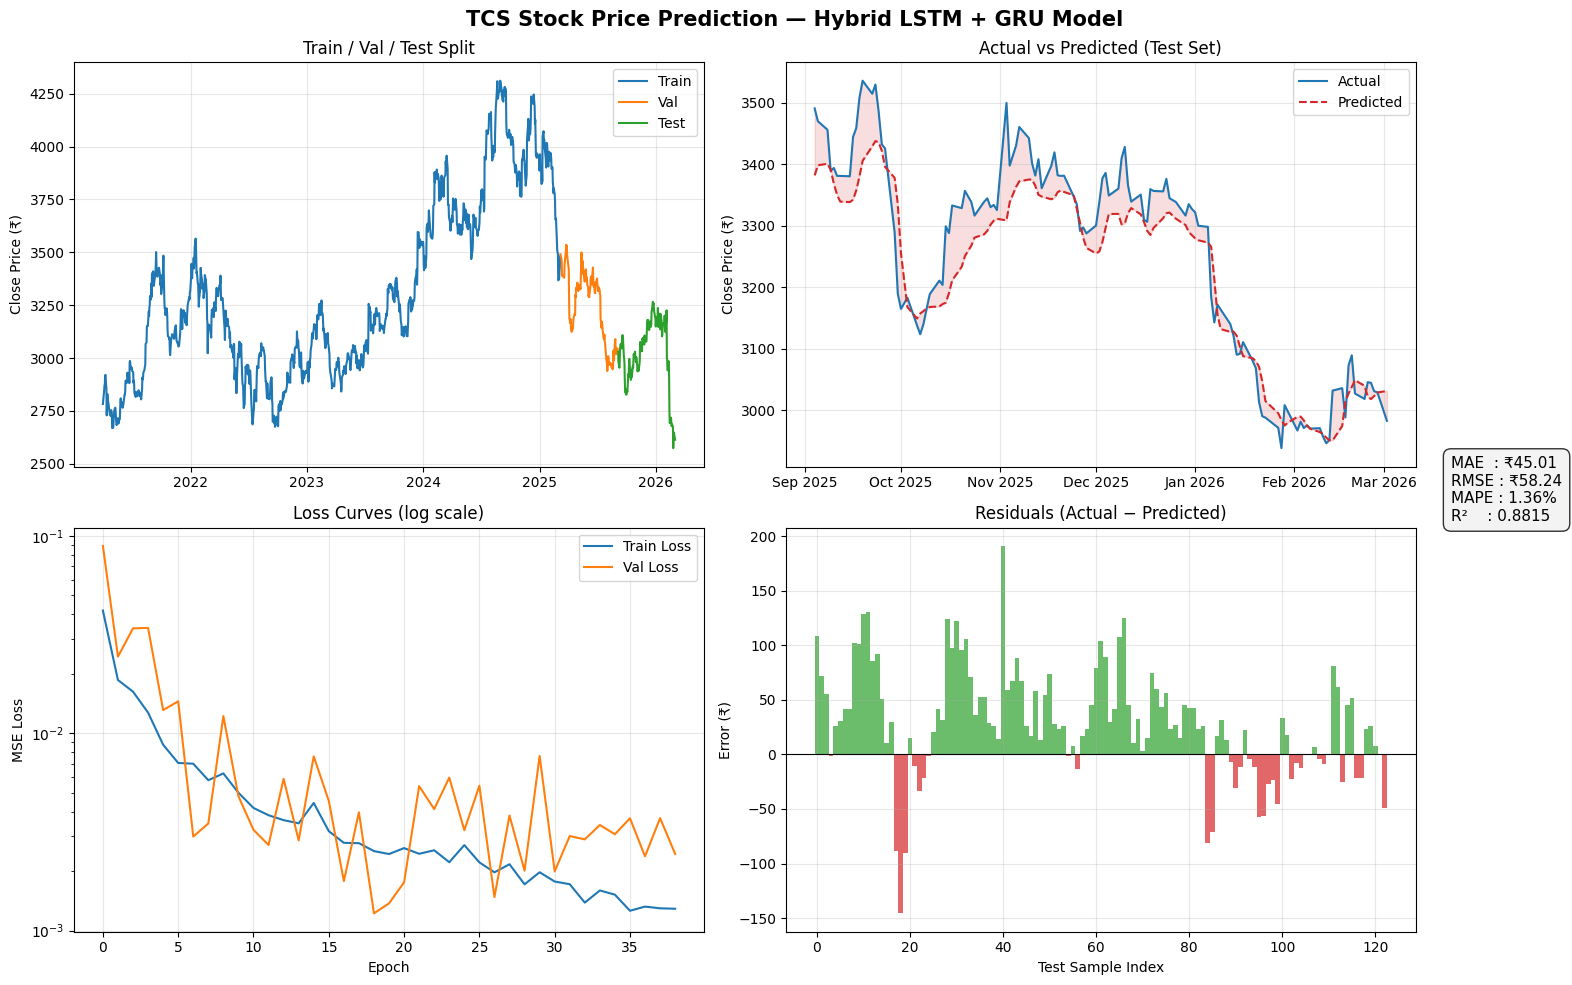

Plot saved → tcs_hybrid_results.png


In [23]:
# ── 14. Plots ─────────────────────────────────────────────────────────────────
test_dates = dates[n_train + n_val : n_train + n_val + len(actuals)]
residuals  = actuals - preds

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("TCS Stock Price Prediction — Hybrid LSTM + GRU Model",
             fontsize=15, fontweight="bold")

# (a) Train / Val / Test split overview
ax = axes[0, 0]
ax.plot(dates[:n_train],
        df["Close"].values[:n_train], label="Train", color="#1f77b4")
ax.plot(dates[n_train : n_train + n_val],
        df["Close"].values[n_train : n_train + n_val], label="Val", color="#ff7f0e")
ax.plot(dates[n_train + n_val : n_train + n_val + len(actuals)],
        df["Close"].values[n_train + n_val : n_train + n_val + len(actuals)],
        label="Test", color="#2ca02c")
ax.set_title("Train / Val / Test Split")
ax.set_ylabel("Close Price (₹)")
ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# (b) Actual vs Predicted
ax = axes[0, 1]
ax.plot(test_dates, actuals, label="Actual",    color="#1f77b4", linewidth=1.5)
ax.plot(test_dates, preds,   label="Predicted", color="#d62728",
        linewidth=1.5, linestyle="--")
ax.fill_between(test_dates, actuals, preds, alpha=0.15, color="#d62728")
ax.set_title("Actual vs Predicted (Test Set)")
ax.set_ylabel("Close Price (₹)")
ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# (c) Loss curves
ax = axes[1, 0]
ax.plot(train_losses, label="Train Loss", color="#1f77b4")
ax.plot(val_losses,   label="Val Loss",   color="#ff7f0e")
ax.set_title("Loss Curves (log scale)")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.legend(); ax.grid(alpha=0.3)
ax.set_yscale("log")

# (d) Residuals
ax = axes[1, 1]
ax.bar(range(len(residuals)), residuals,
       color=np.where(residuals >= 0, "#2ca02c", "#d62728"), alpha=0.7, width=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residuals (Actual − Predicted)")
ax.set_xlabel("Test Sample Index"); ax.set_ylabel("Error (₹)")
ax.grid(alpha=0.3)

metrics_text = (f"MAE  : ₹{mae:.2f}\n"
                f"RMSE : ₹{rmse:.2f}\n"
                f"MAPE : {mape:.2f}%\n"
                f"R²    : {r2:.4f}")
fig.text(0.91, 0.5, metrics_text, fontsize=11,
         verticalalignment="center",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", alpha=0.8))

plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.savefig("tcs_hybrid_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → tcs_hybrid_results.png")

In [24]:
# ── 15. Next-day forecast ─────────────────────────────────────────────────────
last_seq = torch.tensor(
    test_scaled[-SEQ_LEN:][np.newaxis, ...], dtype=torch.float32
).to(DEVICE)

model.eval()
with torch.no_grad():
    next_scaled = model(last_seq).item()

next_price = inverse_close([next_scaled], scaler, close_idx)[0]
print(f"\n📈 Predicted next-day TCS Close Price: ₹{next_price:.2f}")



📈 Predicted next-day TCS Close Price: ₹2781.44


In [25]:
from google.colab import files
files.download("best_hybrid_model.pth")   # downloads the saved model

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files
files.download("gru_lstm.ipynb")

FileNotFoundError: Cannot find file: gru_lstm.ipynb